## 테스트 구간 실제값 vs 예측값

,date,actual_spending,predicted_spending,difference
0,2024-04-16,0,4357,-4357
1,2024-04-17,3429,4701,-1272
2,2024-04-18,5912,3591,2321
3,2024-04-19,4628,4138,490
4,2024-04-20,5074,4668,406
5,2024-04-21,5918,5551,367
6,2024-04-22,3941,4541,-600
7,2024-04-23,5428,4424,1004
8,2024-04-24,3832,4768,-936
9,2024-04-25,5761,3658,2103


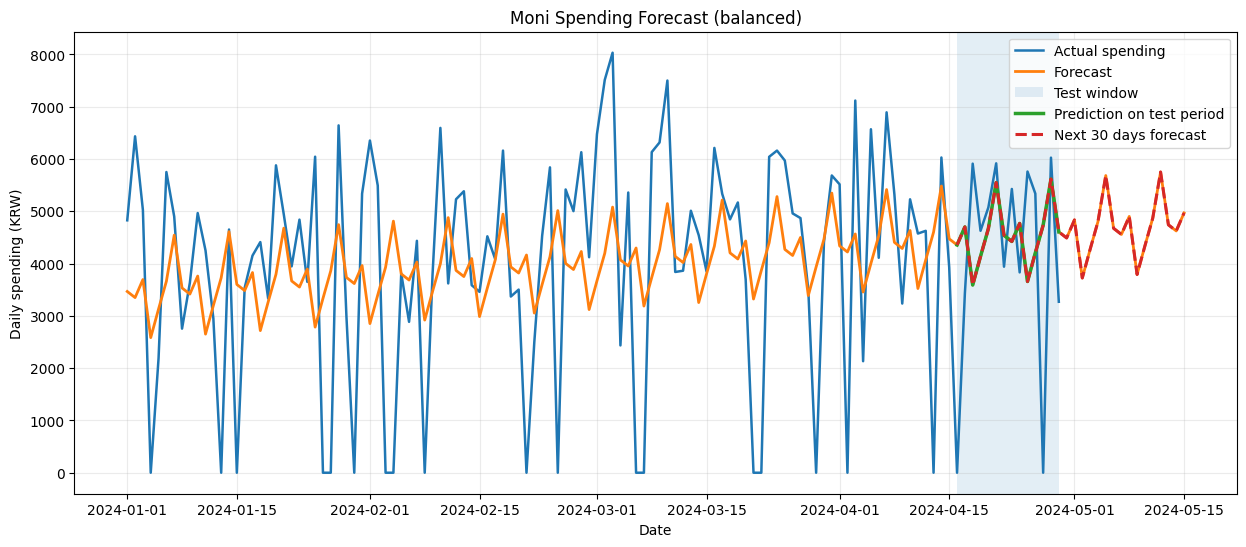

테스트 통과


In [ ]:
# =========================================================
# Moni Pipeline - Colab Full Version
# Copy and paste this into a single Colab cell
# =========================================================

!pip install prophet pandas numpy scikit-learn matplotlib --quiet

import math
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error
from IPython.display import display, HTML, Markdown


# =========================================================
# 0. USER SETTINGS
# =========================================================
# Choose one:
# - "careful"
# - "balanced"
# - "overspend"
# - "custom"
PROFILE = "balanced"

# None -> different result every run
# integer -> reproducible result
SEED = None

# If PROFILE == "custom", these values are used
CUSTOM_BASE_SPEND = 4200
CUSTOM_BUDGET = 150000
CUSTOM_WEEKEND_BOOST = 1800
CUSTOM_PAYDAY_SPIKE = 2500

# Forecast / evaluation settings
HISTORY_DAYS = 120
TEST_DAYS = 14
FORECAST_DAYS = 30


# =========================================================
# 1. STYLE
# =========================================================
def inject_style():
    display(HTML("""
    <style>
    .moni-wrap {
        font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Arial, sans-serif;
        color: #111;
    }

    .moni-section-title {
        font-size: 20px;
        font-weight: 700;
        margin: 28px 0 12px 0;
    }

    .moni-grid-4 {
        display: grid;
        grid-template-columns: repeat(4, minmax(0, 1fr));
        gap: 12px;
        margin-bottom: 12px;
    }

    .moni-grid-3 {
        display: grid;
        grid-template-columns: repeat(3, minmax(0, 1fr));
        gap: 12px;
        margin-bottom: 12px;
    }

    .moni-card {
        border-radius: 18px;
        padding: 18px 18px;
        border: 1px solid #e6e6e6;
        box-shadow: 0 2px 10px rgba(0,0,0,0.04);
        background: white;
    }

    .moni-card-title {
        font-size: 13px;
        color: #666;
        margin-bottom: 8px;
        font-weight: 600;
    }

    .moni-card-value {
        font-size: 24px;
        font-weight: 800;
        color: #111;
        line-height: 1.2;
    }

    .moni-card-sub {
        font-size: 12px;
        color: #777;
        margin-top: 8px;
    }

    .moni-badge {
        display: inline-block;
        padding: 5px 10px;
        border-radius: 999px;
        color: white;
        font-size: 12px;
        font-weight: 700;
        margin-bottom: 10px;
    }

    .moni-kv {
        display: grid;
        grid-template-columns: 180px 1fr;
        row-gap: 8px;
        column-gap: 12px;
        font-size: 14px;
        align-items: start;
    }

    .moni-k {
        color: #666;
        font-weight: 600;
    }

    .moni-v {
        color: #111;
        font-weight: 600;
    }

    .moni-note {
        font-size: 14px;
        color: #444;
        line-height: 1.6;
    }

    .moni-summary-box {
        border-radius: 18px;
        padding: 18px 20px;
        border: 1px solid #e6e6e6;
        background: #fafafa;
        margin-top: 14px;
        line-height: 1.7;
        font-size: 15px;
    }

    @media (max-width: 900px) {
        .moni-grid-4, .moni-grid-3 {
            grid-template-columns: 1fr;
        }
        .moni-kv {
            grid-template-columns: 1fr;
        }
    }
    </style>
    """))


# =========================================================
# 2. HELPERS
# =========================================================
def won(x):
    return f"{int(round(x)):,}원"

def safe_int(x):
    return int(round(float(x)))

def pressure_to_text(pressure):
    if pressure >= 1.20:
        return "높음"
    elif pressure >= 1.00:
        return "주의"
    return "안정"

def difficulty_colors(difficulty):
    if difficulty == "Hard":
        return {
            "bg": "#fff1f1",
            "badge": "#d32f2f",
            "border": "#ffd7d7"
        }
    if difficulty == "Medium":
        return {
            "bg": "#fff8e8",
            "badge": "#ef6c00",
            "border": "#ffe1a8"
        }
    return {
        "bg": "#eef9f0",
        "badge": "#2e7d32",
        "border": "#cfead5"
    }


# =========================================================
# 3. PROFILE CONFIG
# =========================================================
def get_profile_config(profile: str):
    profile = profile.lower()

    configs = {
        "careful": {
            "base_spend": 2600,
            "budget": 120000,
            "weekend_boost": 800,
            "payday_spike": 1000,
            "zero_spend_prob": 0.22,
            "noise_std": 700,
            "trend_per_day": 2,
        },
        "balanced": {
            "base_spend": 3800,
            "budget": 150000,
            "weekend_boost": 1500,
            "payday_spike": 1800,
            "zero_spend_prob": 0.12,
            "noise_std": 900,
            "trend_per_day": 4,
        },
        "overspend": {
            "base_spend": 5200,
            "budget": 145000,
            "weekend_boost": 2600,
            "payday_spike": 3200,
            "zero_spend_prob": 0.05,
            "noise_std": 1100,
            "trend_per_day": 8,
        },
        "custom": {
            "base_spend": CUSTOM_BASE_SPEND,
            "budget": CUSTOM_BUDGET,
            "weekend_boost": CUSTOM_WEEKEND_BOOST,
            "payday_spike": CUSTOM_PAYDAY_SPIKE,
            "zero_spend_prob": 0.10,
            "noise_std": 900,
            "trend_per_day": 4,
        }
    }

    if profile not in configs:
        raise ValueError(f"Unknown profile: {profile}")

    return configs[profile]


# =========================================================
# 4. SYNTHETIC DATA GENERATION
# =========================================================
def generate_cafe_data(days=120, seed=None, profile="balanced"):
    cfg = get_profile_config(profile)

    if seed is None:
        seed = random.randint(1, 999999)

    np.random.seed(seed)

    dates = pd.date_range(start="2024-01-01", periods=days, freq="D")
    values = []

    for i, d in enumerate(dates):
        base = cfg["base_spend"]
        trend = cfg["trend_per_day"] * i
        weekend = cfg["weekend_boost"] if d.weekday() >= 5 else 0
        payday = cfg["payday_spike"] if d.day in [1, 2, 3, 25, 26] else 0

        if np.random.rand() < cfg["zero_spend_prob"]:
            amount = 0
        else:
            noise = np.random.normal(0, cfg["noise_std"])
            amount = max(0, base + trend + weekend + payday + noise)

        values.append(round(amount, 0))

    df = pd.DataFrame({"ds": dates, "y": values})
    return df, seed, cfg


# =========================================================
# 5. SPLIT
# =========================================================
def split_train_test(df, test_days=14):
    train = df.iloc[:-test_days].copy()
    test = df.iloc[-test_days:].copy()
    return train, test


# =========================================================
# 6. MODEL
# =========================================================
def fit_prophet_model(train_df):
    model = Prophet(
        daily_seasonality=False,
        weekly_seasonality=True,
        yearly_seasonality=False,
        changepoint_prior_scale=0.08,
        seasonality_mode="additive"
    )
    model.fit(train_df)
    return model


def forecast_with_model(model, total_future_days):
    future = model.make_future_dataframe(periods=total_future_days, freq="D")
    forecast = model.predict(future)
    return forecast


# =========================================================
# 7. METRICS
# =========================================================
def safe_mape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    mask = y_true != 0
    if mask.sum() == 0:
        return np.nan
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100


def evaluate_forecast(test_df, eval_forecast_df):
    actual = test_df["y"].values
    pred = eval_forecast_df["yhat"].values[:len(test_df)]

    mae = mean_absolute_error(actual, pred)
    rmse = math.sqrt(mean_squared_error(actual, pred))
    mape = safe_mape(actual, pred)

    return {
        "mae": mae,
        "rmse": rmse,
        "mape": mape,
        "actual": actual,
        "pred": pred
    }


# =========================================================
# 8. BEHAVIOR SUMMARY
# =========================================================
def count_no_spend_streak(values):
    streak = 0
    for v in reversed(values):
        if v <= 0:
            streak += 1
        else:
            break
    return streak


def summarize_behavior(df, future_forecast_df, monthly_budget):
    recent_7_avg = df["y"].tail(7).mean()
    recent_14_sum = df["y"].tail(14).sum()
    yesterday_spend = df["y"].iloc[-1]
    no_spend_streak = count_no_spend_streak(df["y"].tolist())

    projected_30d_total = future_forecast_df["yhat"].head(30).sum()
    budget_pressure = projected_30d_total / monthly_budget
    budget_gap = projected_30d_total - monthly_budget

    return {
        "recent_7_avg": recent_7_avg,
        "recent_14_sum": recent_14_sum,
        "yesterday_spend": yesterday_spend,
        "no_spend_streak": no_spend_streak,
        "projected_30d_total": projected_30d_total,
        "budget_pressure": budget_pressure,
        "budget_gap": budget_gap,
    }


# =========================================================
# 9. CHALLENGE ENGINE
# =========================================================
def generate_challenge(summary):
    pressure = summary["budget_pressure"]
    yesterday = summary["yesterday_spend"]
    avg7 = summary["recent_7_avg"]
    streak = summary["no_spend_streak"]

    reasons = []

    if pressure >= 1.20:
        difficulty = "Hard"
        reward_xp = 30
    elif pressure >= 1.00:
        difficulty = "Medium"
        reward_xp = 20
    else:
        difficulty = "Easy"
        reward_xp = 12

    if pressure >= 1.20:
        reasons.append("예상 월 소비가 예산을 20% 이상 초과하고 있습니다.")
    elif pressure >= 1.00:
        reasons.append("예상 월 소비가 예산을 초과할 가능성이 있습니다.")
    else:
        reasons.append("현재 소비 페이스가 예산 범위 안에 있습니다.")

    if yesterday > avg7 * 1.35 and yesterday > 0:
        reasons.append("어제 소비가 최근 7일 평균보다 높았습니다.")
    elif streak >= 2:
        reasons.append("최근 무지출 streak가 유지되고 있습니다.")

    if difficulty == "Hard":
        if yesterday > avg7 * 1.35 and yesterday > 0:
            challenge_type = "금지형"
            challenge_text = "오늘 카페 지출 0원 유지하기"
        else:
            challenge_type = "강한 제한형"
            challenge_text = "오늘 카페 3,000원 이하로 유지하기"

    elif difficulty == "Medium":
        if streak >= 2:
            challenge_type = "streak 유지형"
            challenge_text = f"무지출 streak {streak + 1}일째 이어가기"
        else:
            challenge_type = "제한형"
            challenge_text = "오늘 카페 5,000원 이하로 유지하기"

    else:
        if streak >= 1:
            challenge_type = "완만한 streak형"
            challenge_text = f"무지출 streak {streak + 1}일째 도전하기"
        else:
            challenge_type = "유지형"
            challenge_text = "오늘 카페 8,000원 이하로 가볍게 유지하기"

    return {
        "difficulty": difficulty,
        "challenge_type": challenge_type,
        "challenge_text": challenge_text,
        "reward_xp": reward_xp,
        "reasons": reasons
    }


# =========================================================
# 10. UI BLOCKS
# =========================================================
def show_header(profile, seed):
    html = f"""
    <div class="moni-wrap">
        <div class="moni-section-title">Moni Demo</div>
        <div class="moni-card">
            <div class="moni-kv">
                <div class="moni-k">Profile</div><div class="moni-v">{profile}</div>
                <div class="moni-k">Seed</div><div class="moni-v">{seed}</div>
            </div>
        </div>
    </div>
    """
    display(HTML(html))


def show_top_summary_cards(summary, budget):
    html = f"""
    <div class="moni-wrap">
        <div class="moni-section-title">핵심 요약</div>
        <div class="moni-grid-4">
            <div class="moni-card">
                <div class="moni-card-title">최근 7일 평균 소비</div>
                <div class="moni-card-value">{won(summary['recent_7_avg'])}</div>
                <div class="moni-card-sub">최근 소비 흐름의 평균값</div>
            </div>

            <div class="moni-card">
                <div class="moni-card-title">어제 소비</div>
                <div class="moni-card-value">{won(summary['yesterday_spend'])}</div>
                <div class="moni-card-sub">직전 하루 소비 금액</div>
            </div>

            <div class="moni-card">
                <div class="moni-card-title">예상 30일 총 소비</div>
                <div class="moni-card-value">{won(summary['projected_30d_total'])}</div>
                <div class="moni-card-sub">향후 30일 예측 합계</div>
            </div>

            <div class="moni-card">
                <div class="moni-card-title">예산 대비 소비 비율</div>
                <div class="moni-card-value">{summary['budget_pressure'] * 100:.1f}%</div>
                <div class="moni-card-sub">상태: {pressure_to_text(summary['budget_pressure'])}</div>
            </div>
        </div>
    </div>
    """
    display(HTML(html))


def show_metrics_block(metrics):
    mape_text = "-" if np.isnan(metrics["mape"]) else f"{metrics['mape']:.2f}%"

    html = f"""
    <div class="moni-wrap">
        <div class="moni-section-title">예측 성능</div>
        <div class="moni-grid-3">
            <div class="moni-card">
                <div class="moni-card-title">MAE</div>
                <div class="moni-card-value">{won(metrics['mae'])}</div>
                <div class="moni-card-sub">평균 절대 오차</div>
            </div>
            <div class="moni-card">
                <div class="moni-card-title">RMSE</div>
                <div class="moni-card-value">{won(metrics['rmse'])}</div>
                <div class="moni-card-sub">큰 오차에 더 민감한 지표</div>
            </div>
            <div class="moni-card">
                <div class="moni-card-title">MAPE</div>
                <div class="moni-card-value">{mape_text}</div>
                <div class="moni-card-sub">상대적 오차율</div>
            </div>
        </div>
    </div>
    """
    display(HTML(html))


def show_budget_block(summary, budget):
    gap_text = won(summary["budget_gap"]) if summary["budget_gap"] >= 0 else f"-{won(abs(summary['budget_gap']))}"
    gap_label = "예산 초과 예상" if summary["budget_gap"] >= 0 else "예산 여유 예상"

    html = f"""
    <div class="moni-wrap">
        <div class="moni-section-title">소비 및 예산 상태</div>
        <div class="moni-card">
            <div class="moni-kv">
                <div class="moni-k">최근 14일 총 소비</div><div class="moni-v">{won(summary['recent_14_sum'])}</div>
                <div class="moni-k">현재 무지출 streak</div><div class="moni-v">{summary['no_spend_streak']}일</div>
                <div class="moni-k">월 예산</div><div class="moni-v">{won(budget)}</div>
                <div class="moni-k">{gap_label}</div><div class="moni-v">{gap_text}</div>
            </div>
        </div>
    </div>
    """
    display(HTML(html))


def show_challenge_block(challenge):
    colors = difficulty_colors(challenge["difficulty"])
    reasons_html = "".join([f"<li>{r}</li>" for r in challenge["reasons"]])

    html = f"""
    <div class="moni-wrap">
        <div class="moni-section-title">오늘의 챌린지</div>
        <div class="moni-card" style="background:{colors['bg']}; border-color:{colors['border']};">
            <span class="moni-badge" style="background:{colors['badge']};">{challenge['difficulty']}</span>
            <div style="font-size:14px; color:#666; font-weight:600; margin-bottom:6px;">{challenge['challenge_type']}</div>
            <div style="font-size:28px; font-weight:800; line-height:1.3; margin-bottom:10px;">
                {challenge['challenge_text']}
            </div>
            <div style="font-size:15px; margin-bottom:12px;">
                보상 XP: <b>+{challenge['reward_xp']}</b>
            </div>
            <div class="moni-note">
                <b>생성 이유</b>
                <ul style="margin-top:8px; margin-bottom:0;">
                    {reasons_html}
                </ul>
            </div>
        </div>
    </div>
    """
    display(HTML(html))


def show_prediction_table(test_df, eval_forecast_df):
    preview = pd.DataFrame({
        "date": test_df["ds"].dt.strftime("%Y-%m-%d").values,
        "actual_spending": test_df["y"].round(0).astype(int).values,
        "predicted_spending": eval_forecast_df["yhat"].round(0).astype(int).values,
    })
    preview["difference"] = preview["actual_spending"] - preview["predicted_spending"]

    display(Markdown("## 테스트 구간 실제값 vs 예측값"))
    display(preview)


def show_final_summary(summary, challenge, budget):
    budget_status = "초과 가능성" if summary["budget_pressure"] >= 1.0 else "예산 범위 유지 가능성"

    html = f"""
    <div class="moni-wrap">
        <div class="moni-section-title">실행 결과 요약</div>
        <div class="moni-summary-box">
            이 사용자의 향후 30일 예상 소비는 <b>{won(summary["projected_30d_total"])}</b> 입니다.<br>
            월 예산 <b>{won(budget)}</b> 대비 소비 비율은 <b>{summary["budget_pressure"] * 100:.1f}%</b> 이며,
            현재 상태는 <b>{budget_status}</b> 으로 해석됩니다.<br>
            따라서 오늘의 개인화 챌린지는 <b>{challenge["challenge_text"]}</b> 로 생성되었습니다.
        </div>
    </div>
    """
    display(HTML(html))


# =========================================================
# 11. VISUALIZATION
# =========================================================
def plot_results(df, train, test, full_forecast, eval_forecast, future_forecast, profile):
    plt.figure(figsize=(15, 6))

    plt.plot(df["ds"], df["y"], label="Actual spending", linewidth=1.8)
    plt.plot(full_forecast["ds"], full_forecast["yhat"], label="Forecast", linewidth=2)

    plt.axvspan(test["ds"].iloc[0], test["ds"].iloc[-1], alpha=0.12, label="Test window")

    plt.plot(
        eval_forecast["ds"],
        eval_forecast["yhat"],
        linewidth=2.5,
        label="Prediction on test period"
    )

    plt.plot(
        future_forecast["ds"].head(30),
        future_forecast["yhat"].head(30),
        linestyle="--",
        linewidth=2.2,
        label="Next 30 days forecast"
    )

    plt.title(f"Moni Spending Forecast ({profile})")
    plt.xlabel("Date")
    plt.ylabel("Daily spending (KRW)")
    plt.grid(alpha=0.25)
    plt.legend()
    plt.show()


# =========================================================
# 12. PIPELINE
# =========================================================
def run_pipeline(profile="balanced", seed=None):
    # Data
    df, used_seed, cfg = generate_cafe_data(
        days=HISTORY_DAYS,
        seed=seed,
        profile=profile
    )
    train, test = split_train_test(df, test_days=TEST_DAYS)

    # Model
    model = fit_prophet_model(train)

    # Forecast full history + future
    full_forecast = forecast_with_model(model, total_future_days=FORECAST_DAYS)

    # Forecast slices
    train_len = len(train)
    test_len = len(test)

    eval_forecast = full_forecast.iloc[train_len:train_len + test_len].copy()
    future_forecast = full_forecast.iloc[train_len:].copy()

    # Metrics
    metrics = evaluate_forecast(test, eval_forecast)

    # Behavioral summary
    summary = summarize_behavior(
        df=df,
        future_forecast_df=future_forecast,
        monthly_budget=cfg["budget"]
    )

    # Challenge
    challenge = generate_challenge(summary)

    # Basic checks
    assert metrics["mae"] >= 0
    assert challenge["challenge_text"] is not None
    assert challenge["difficulty"] in ["Easy", "Medium", "Hard"]

    # UI
    inject_style()
    show_header(profile, used_seed)
    show_top_summary_cards(summary, cfg["budget"])
    show_metrics_block(metrics)
    show_budget_block(summary, cfg["budget"])
    show_challenge_block(challenge)
    show_prediction_table(test, eval_forecast)
    plot_results(df, train, test, full_forecast, eval_forecast, future_forecast, profile)
    show_final_summary(summary, challenge, cfg["budget"])

    print("테스트 통과")

    return {
        "profile": profile,
        "seed": used_seed,
        "budget": cfg["budget"],
        "df": df,
        "train": train,
        "test": test,
        "full_forecast": full_forecast,
        "eval_forecast": eval_forecast,
        "future_forecast": future_forecast,
        "metrics": metrics,
        "summary": summary,
        "challenge": challenge,
    }


# =========================================================
# 13. RUN
# =========================================================
results = run_pipeline(profile=PROFILE, seed=SEED)